In [1]:
import sys
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage,BaseMessage
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
load_env()
#model =ChatOpenAI()
from langgraph.graph import StateGraph,START, END

from typing import TypedDict,Annotated,Literal
from langgraph.checkpoint.memory import InMemorySaver
import operator
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from pydantic import BaseModel,Field
from langgraph.types import interrupt,Command

c:\Users\Dharmendra Vartika\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# model=ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash-lite",   # or gemini-2.0-pro, 1.5-pro, etc.
#     temperature=0.2
# )
model =ChatOpenAI()
class stock(BaseModel):
    symbol:str = Field(description="fetch the stock symbol only")
model_with_Stock=model.with_structured_output(stock)

c:\Users\Dharmendra Vartika\AppData\Local\Programs\Python\Python313\Lib\site-packages\langchain_openai\chat_models\base.py:1963: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [3]:
model_with_Stock.invoke("can you get me latest price of QSI stock").symbol

'QSI'

In [8]:
search_Tavily = TavilySearchResults(max_results=2)
import requests
@tool
def get_stock_price(state:bot) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    output=state['messages'][-1].content
    symbol=model_with_Stock.invoke(output)
    symbol=symbol.symbol
    print('stock is ',symbol)
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()

@tool
def buy_stock(symbol: str) -> str:
    """
    buy the stock  (e.g. 'AAPL', 'TSLA') 
    """
    #decision =staet
    decission=interrupt(f"approve buying {symbol} stock")
    if decission=='Approve':
    
    #url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
        output=f"i have bought the shares of {symbol}"
    #r = requests.get(url)
        return output
    else:
        output=f"Decline the shares of {symbol}"
    #r = requests.get(url)
        return output 
    


In [45]:
tools = [search_Tavily]
llm_with_tools = model.bind_tools(tools)

In [46]:
class bot(TypedDict):
    messages :Annotated[list[BaseMessage],add_messages]
   # decision :Literal["Approve","Reject"]
# class bot(TypedDict):
#     messages :list

In [47]:
from langgraph.types import CachePolicy
from langgraph.cache.memory import InMemoryCache

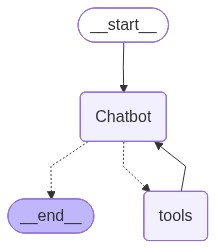

In [48]:
def Chatbot(state:bot):
    text =state['messages']
    #messages =[HumanMessage(text)]
    result=llm_with_tools.invoke (text)
    #messages =[AIMessage(result.content)]
        #print ('AI response is ',result.content)
    return {'messages' :[result]}
checkpoint =InMemorySaver()
#conn = sqlite3.connect(database='chatbot_dharmendra.db', check_same_thread=False)
# Checkpointer
Checkpointer = checkpoint
tool_node = ToolNode(tools)
graph=StateGraph(bot)
graph.add_node('Chatbot',Chatbot,cache_policy=CachePolicy(ttl=20))
graph.add_node('tools',tool_node)
graph.add_edge(START,'Chatbot')
graph.add_conditional_edges('Chatbot',tools_condition)
graph.add_edge('tools','Chatbot')
graph.add_edge('Chatbot',END)
workflow=graph.compile(checkpointer=Checkpointer,cache=InMemoryCache())
workflow


In [187]:
#CONFIG = {'configurable': {'thread_id': 3}}

In [51]:
CONFIG = {'configurable': {'thread_id': 8}}
user_input='what is 2+2'
initial_state={'messages':[HumanMessage(content=user_input)]}
result=workflow.invoke(initial_state,config=CONFIG, stream_mode='updates')

In [50]:
result

[{'Chatbot': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 87, 'total_tokens': 146, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-D0RMLLWdAAFEWmivtuHF8JMCLRJbc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019be078-5446-7af2-b32b-2dbaab3d5384-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '2+2'}, 'id': 'call_tuLFxA8acSpaC4lwV7SnGrc0', 'type': 'tool_call'}, {'name': 'tavily_search_results_json', 'args': {'query': 'what is 2 plus 2'}, 'id': 'call_U1jvyH2VH9JPq9wDbCxS9rjV', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 87,

In [52]:
result

[{'Chatbot': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 2653, 'total_tokens': 2673, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-D0RMhsDdfbkZD7re1rdfOElD5obFZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019be078-ab2f-71a1-969e-fffa7cdb6482-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '2+2'}, 'id': 'call_xizQDXubWa40Pcyjj6xdpDYZ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2653, 'output_tokens': 20, 'total_tokens': 2673, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0,

In [113]:
decission='Decline'
workflow.invoke(Command(resume =decission),config=CONFIG)

{'messages': [HumanMessage(content='buy me stock of APPLE', additional_kwargs={}, response_metadata={}, id='e340c8a9-753e-4026-a2f5-234bd995f524'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 167, 'total_tokens': 182, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CjfSdqB64mBxMle6DC84efRq9JdPn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--59501aaa-3fc7-48fb-8c95-1d32754d5f9b-0', tool_calls=[{'name': 'buy_stock', 'args': {'symbol': 'AAPL'}, 'id': 'call_3KT32ca6qKTK81aSUmcfcDq8', 'type': 'tool_call'}], usage_metadata={'input_tokens': 167, 'output_tokens': 15, 'total_tokens': 182, 'input_to

In [48]:
CONFIG = {'configurable': {'thread_id': 8}}
user_input='Can you get me top 20 news of Mumbai , weather of Mumbai and stock price of APPLE'
initial_state={'messages':[HumanMessage(content=user_input)]}
result=workflow.invoke(initial_state,config=CONFIG,stream_mode='values')

In [190]:
result

{'messages': [HumanMessage(content='can you get me latest price of QSI stock', additional_kwargs={}, response_metadata={}, id='44e76412-b3e9-40fa-843c-3acdaf10fcdd'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 190, 'total_tokens': 218, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Cjg7sm04DxLj4uMAS6Ep9f48srYa3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--3c98dc0e-9a20-42a3-a57d-248bda5835bb-0', tool_calls=[{'name': 'get_stock_price', 'args': {'state': {'messages': [{'content': 'QSI', 'type': 'get_stock_price'}]}}, 'id': 'call_0gXZ1FUGYJNV4fKjRak0WjcN', 'type': 'tool_call'}], usage_met

In [100]:
result['messages'][-1].pretty_print()

================================== Ai Message ==================================

The latest stock price of Apple (AAPL) is $278.78.
